# NB 05 — ROM Prediction

Online prediction interface. Given any $(k, S)$ within the training range and any user-defined rate schedule $q(t)$, produce the full spatial pressure field and BHP time series without running MRST.

*Ref.* Peherstorfer & Willcox (2016), Section 3.4 — the online phase of the nonintrusive reduced model.

---

## Online prediction workflow

1. User specifies $(k^*, S^*)$ and a rate schedule
2. Operators $\hat{A}^*, \hat{B}^*, \hat{C}^*$ are obtained by evaluating the RBF interpolants at $(\log_{10} k^*, S^*)$
3. The $n$-dimensional reduced ODE is integrated forward with implicit Euler
4. Full pressure field reconstructed: $p(t) = p_{\text{init}} + V_n \tilde{x}(t)$
5. BHP: $\text{BHP}(t) = p_{\text{init}} + \hat{C}^* \tilde{x}(t)$

Total wall time: **< 1 second** regardless of time grid length.

---

## Rate schedule format

Specify piecewise-constant rate as a list of `(change_time_hr, rate_STBd)` pairs. Rate is constant at the last specified value after the final change time:

```python
# Example: three-period schedule
rate_schedule = [
    (0,    900),   # 0 to 1000 hr  : 900 STB/d
    (1000, 500),   # 1000 to 3000 hr: 500 STB/d
    (3000, 0  ),   # 3000 to 5000 hr: shut-in
]
```

The schedule is interpolated onto the simulation time grid automatically.

---
## 0. Imports and paths

In [25]:
import json
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

BASIS_DIR   = Path('../rom/basis')
INTERP_DIR  = Path('../rom/interpolants')
RESULTS_DIR = Path('../results/predictions')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

P_INIT    = 4500.0
NX, NY    = 50, 50
T_END_HR  = 5000.0
N_STEPS   = 350

Vn     = np.load(BASIS_DIR / 'Vn.npy')
n      = Vn.shape[1]

with open(INTERP_DIR / 'A_hat_interp.pkl', 'rb') as f:
    A_pkg = pickle.load(f)
with open(INTERP_DIR / 'B_hat_interp.pkl', 'rb') as f:
    B_pkg = pickle.load(f)
with open(INTERP_DIR / 'C_hat_interp.pkl', 'rb') as f:
    C_pkg = pickle.load(f)

A_interps, A_shape = A_pkg['interps'], A_pkg['shape']
B_interps, B_shape = B_pkg['interps'], B_pkg['shape']
C_interps, C_shape = C_pkg['interps'], C_pkg['shape']

print(f'ROM loaded  |  n = {n} modes')

ROM loaded  |  n = 10 modes


---
## 1. Utility functions

In [26]:
def make_time_grid(t_start_hr=0.001, t_end_hr=T_END_HR, n_steps=N_STEPS):
    return np.logspace(np.log10(t_start_hr), np.log10(t_end_hr), n_steps)


def schedule_to_qvec(rate_schedule, t_hr):
    """
    Convert a list of (start_time_hr, rate_STBd) pairs to a q vector
    on the given time grid. Rate is piecewise constant.
    """
    q = np.full(len(t_hr), float(rate_schedule[0][1]))
    for i in range(1, len(rate_schedule)):
        t_change, r = rate_schedule[i]
        q[t_hr >= t_change] = float(r)
    return q


def predict(k_star, s_star, rate_schedule,
            t_start_hr=0.001, t_end_hr=T_END_HR, n_steps=N_STEPS):
    """
    Full ROM prediction pipeline.

    Parameters
    ----------
    k_star        : permeability [mD],  must be in [5, 500]
    s_star        : skin factor  [-],   must be in [0, 15]
    rate_schedule : list of (start_time_hr, rate_STBd) pairs

    Returns
    -------
    result : dict with keys
        t_hr      [N_steps]     time grid
        bhp_psia  [N_steps]     BHP time series
        dp_psi    [N_steps]     drawdown = p_init - BHP
        p_field   [N, N_steps]  full pressure field reconstruction
        q_vec     [N_steps]     rate schedule on time grid
        stable    bool          stability flag of interpolated A
        wall_ms   float         computation time in ms
    """
    assert 5 <= k_star <= 500,  f'k={k_star} outside training range [5, 500] mD'
    assert 0 <= s_star <= 15,   f'S={s_star} outside training range [0, 15]'

    t0  = time.perf_counter()

    t_hr = make_time_grid(t_start_hr, t_end_hr, n_steps)
    q    = schedule_to_qvec(rate_schedule, t_hr)

    pt     = np.array([[np.log10(k_star), s_star]])
    A_hat  = np.array([f(pt)[0] for f in A_interps]).reshape(A_shape)
    B_hat  = np.array([f(pt)[0] for f in B_interps]).reshape(B_shape)
    C_hat  = np.array([f(pt)[0] for f in C_interps]).reshape(C_shape)

    stable = bool(np.max(np.linalg.eigvals(A_hat).real) < 0)

    dt    = np.diff(t_hr * 3600.0, prepend=0.0)
    dt[0] = t_hr[0] * 3600.0
    K     = len(t_hr)
    In    = np.eye(n)

    X_rom = np.zeros((K, n))
    Y_rom = np.zeros(K)
    xk    = np.zeros(n)

    for j in range(K):
        dtj = dt[j]
        rhs = xk + dtj * (B_hat.ravel() * q[j])
        xk  = np.linalg.solve(In - dtj * A_hat, rhs)
        X_rom[j] = xk
        Y_rom[j] = float(C_hat @ xk)

    p_field  = P_INIT + Vn @ X_rom.T    # [N, K]
    bhp_psia = P_INIT + Y_rom

    wall_ms = (time.perf_counter() - t0) * 1000

    return dict(
        t_hr     = t_hr,
        bhp_psia = bhp_psia,
        dp_psi   = P_INIT - bhp_psia,
        p_field  = p_field,
        q_vec    = q,
        stable   = stable,
        wall_ms  = wall_ms,
    )


print('Prediction functions defined.')

Prediction functions defined.


---
## 2. Example 1 — Constant rate drawdown

Reproduce a case close to the original baseline (k = 20 mD, S = 2, constant 800 STB/d) as a sanity check. The log-log diagnostic should show the expected WBS, MTR, and BDF signatures.

C:\Users\hp\AppData\Local\Temp\ipykernel_15244\3999467153.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_rom[j] = float(C_hat @ xk)


Wall time : 7.7 ms
Stable    : True
BHP range : 1965.6 – 4222.0 psia


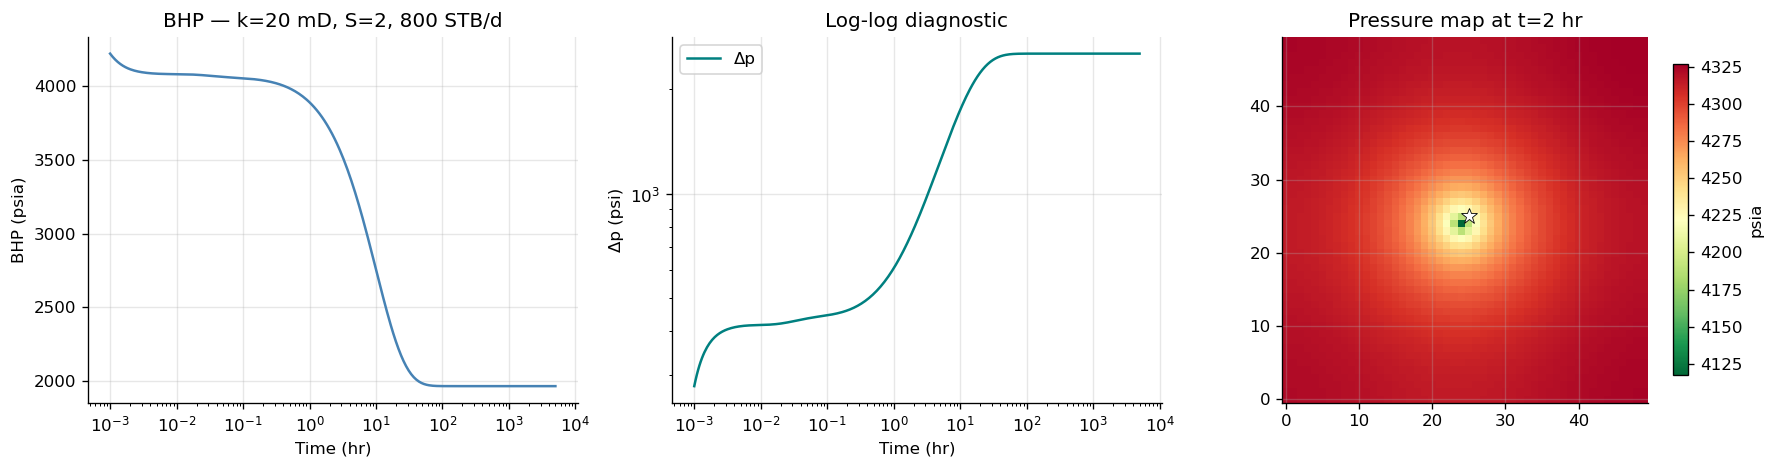

In [27]:
r1 = predict(
    k_star        = 20,
    s_star        = 2,
    rate_schedule = [(0, 800)],
)
print(f'Wall time : {r1["wall_ms"]:.1f} ms')
print(f'Stable    : {r1["stable"]}')
print(f'BHP range : {r1["bhp_psia"].min():.1f} – {r1["bhp_psia"].max():.1f} psia')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogx(r1['t_hr'], r1['bhp_psia'], lw=1.5, color='steelblue')
axes[0].set_xlabel('Time (hr)')
axes[0].set_ylabel('BHP (psia)')
axes[0].set_title('BHP — k=20 mD, S=2, 800 STB/d')

axes[1].loglog(r1['t_hr'], r1['dp_psi'], lw=1.5, color='teal', label='Δp')
axes[1].set_xlabel('Time (hr)')
axes[1].set_ylabel('Δp (psi)')
axes[1].set_title('Log-log diagnostic')
axes[1].legend()

snap_idx = N_STEPS // 2
im = axes[2].imshow(r1['p_field'][:, snap_idx].reshape(NY, NX),
                    origin='lower', cmap='RdYlGn_r')
axes[2].plot(NX//2, NY//2, 'w*', ms=10, markeredgecolor='k', markeredgewidth=0.5)
axes[2].set_title(f'Pressure map at t={r1["t_hr"][snap_idx]:.0f} hr')
plt.colorbar(im, ax=axes[2], label='psia', shrink=0.85)

plt.tight_layout()
plt.show()

---
## 3. Example 2 — User-defined multi-step schedule

Demonstrate the arbitrary rate scheduling capability. Edit any of the parameters below freely.

C:\Users\hp\AppData\Local\Temp\ipykernel_15244\3999467153.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_rom[j] = float(C_hat @ xk)


Wall time : 7.2 ms  |  Stable: False
BHP range : -25340096032954677131923685376.0 – 24680113139136457310512087040.0 psia


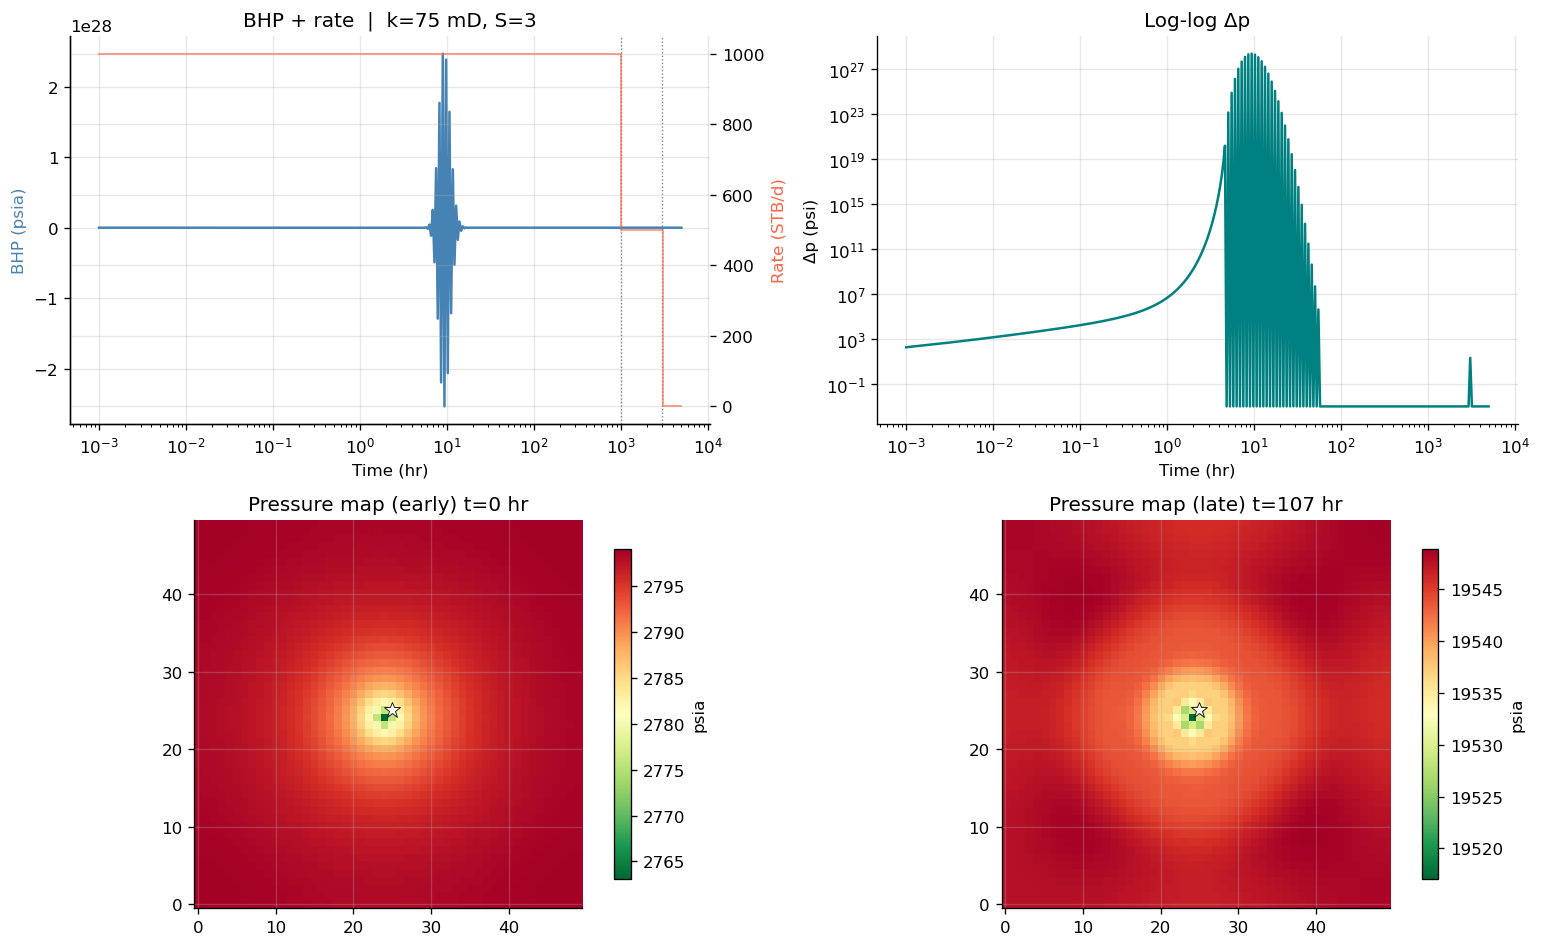

In [28]:
# ── USER INPUTS ──────────────────────────────────────────────────────────
k_query = 75        # mD   — between training grid points
S_query = 3         # skin — between training grid points

rate_schedule = [
    (0,    1000),   # drawdown at 1000 STB/d
    (1000,  500),   # reduce rate
    (3000,    0),   # shut-in
]
# ─────────────────────────────────────────────────────────────────────────

r2 = predict(k_query, S_query, rate_schedule)
print(f'Wall time : {r2["wall_ms"]:.1f} ms  |  Stable: {r2["stable"]}')
print(f'BHP range : {r2["bhp_psia"].min():.1f} – {r2["bhp_psia"].max():.1f} psia')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
ax2 = ax.twinx()
ax.semilogx(r2['t_hr'], r2['bhp_psia'], lw=1.5, color='steelblue', label='BHP')
ax2.step(r2['t_hr'], r2['q_vec'], color='tomato', lw=1.0, alpha=0.7,
         where='post', label='Rate')
ax.set_xlabel('Time (hr)')
ax.set_ylabel('BHP (psia)', color='steelblue')
ax2.set_ylabel('Rate (STB/d)', color='tomato')
ax.set_title(f'BHP + rate  |  k={k_query} mD, S={S_query}')
for tc, _ in rate_schedule[1:]:
    ax.axvline(tc, color='gray', ls=':', lw=0.8)

axes[0, 1].loglog(r2['t_hr'], np.maximum(r2['dp_psi'], 1e-3),
                  lw=1.5, color='teal')
axes[0, 1].set_xlabel('Time (hr)')
axes[0, 1].set_ylabel('Δp (psi)')
axes[0, 1].set_title('Log-log Δp')

snap_early = N_STEPS // 5
snap_late  = N_STEPS * 3 // 4

for idx, (snap, label) in enumerate([(snap_early, 'early'),
                                      (snap_late,  'late')]):
    ax = axes[1, idx]
    im = ax.imshow(r2['p_field'][:, snap].reshape(NY, NX),
                   origin='lower', cmap='RdYlGn_r')
    ax.plot(NX//2, NY//2, 'w*', ms=10, markeredgecolor='k', markeredgewidth=0.5)
    ax.set_title(f'Pressure map ({label}) t={r2["t_hr"][snap]:.0f} hr')
    plt.colorbar(im, ax=ax, label='psia', shrink=0.85)

plt.tight_layout()
plt.show()

---
## 4. Parametric sweep — BHP vs k at fixed S

Demonstrate instant parametric prediction. Compute BHP for 10 values of $k$ at fixed $S$ with constant rate — a task that would require 10 separate MRST runs without the ROM.

C:\Users\hp\AppData\Local\Temp\ipykernel_15244\3999467153.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_rom[j] = float(C_hat @ xk)


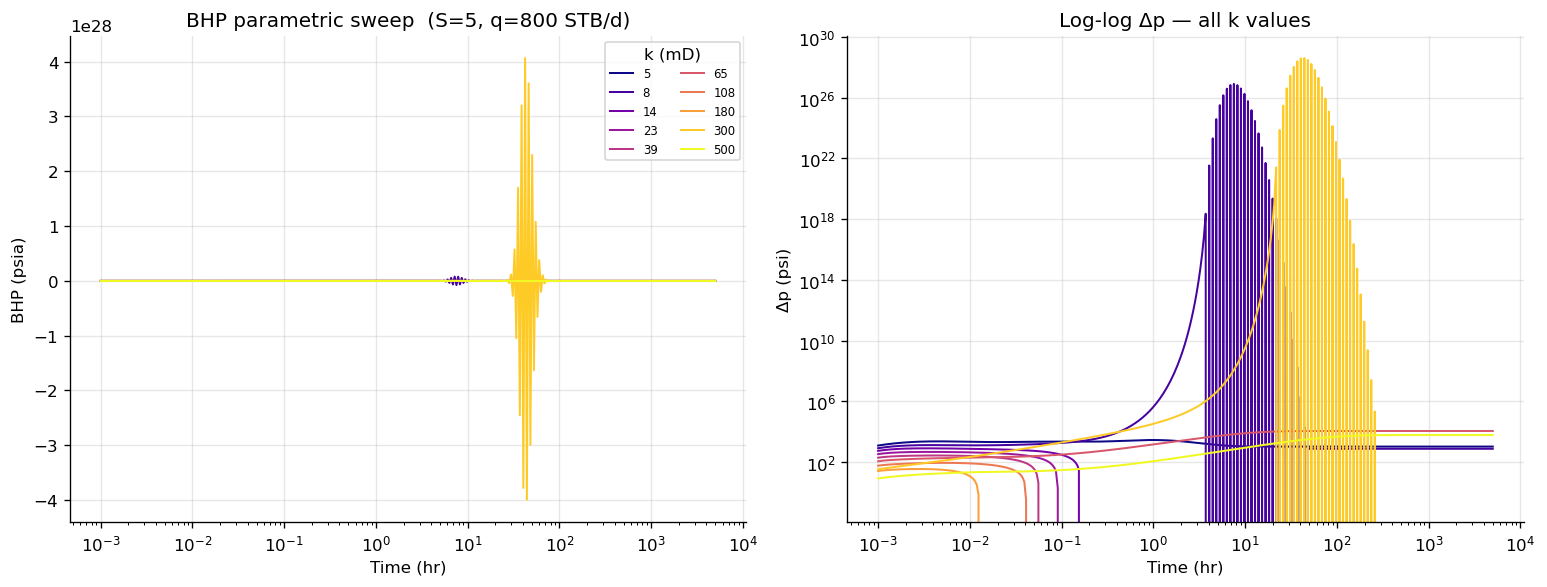

10 predictions in 87 ms total  (8.7 ms each)


In [29]:
k_sweep   = np.logspace(np.log10(5), np.log10(500), 10)
S_fixed   = 5
q_const   = [(0, 800)]

cmap   = plt.cm.plasma
colors = [cmap(i / (len(k_sweep) - 1)) for i in range(len(k_sweep))]

t_start_sweep = time.perf_counter()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for k_v, col in zip(k_sweep, colors):
    res = predict(k_v, S_fixed, q_const)
    axes[0].semilogx(res['t_hr'], res['bhp_psia'],
                     color=col, lw=1.2, label=f'{k_v:.0f}')
    axes[1].loglog(res['t_hr'], res['dp_psi'],
                   color=col, lw=1.2)

total_sweep_ms = (time.perf_counter() - t_start_sweep) * 1000

axes[0].set_xlabel('Time (hr)')
axes[0].set_ylabel('BHP (psia)')
axes[0].set_title(f'BHP parametric sweep  (S={S_fixed}, q=800 STB/d)')
axes[0].legend(title='k (mD)', fontsize=7, ncol=2)

axes[1].set_xlabel('Time (hr)')
axes[1].set_ylabel('Δp (psi)')
axes[1].set_title('Log-log Δp — all k values')

plt.tight_layout()
plt.show()

print(f'10 predictions in {total_sweep_ms:.0f} ms total  ({total_sweep_ms/10:.1f} ms each)')

---
## 5. Save prediction results

Log the query and save outputs to `results/predictions/` for reproducibility.

In [30]:
import datetime

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
pred_name = f'k{k_query:03d}_s{S_query:02d}_{timestamp}'
pred_dir  = RESULTS_DIR / pred_name
pred_dir.mkdir(parents=True, exist_ok=True)

np.save(pred_dir / 't_hr.npy',      r2['t_hr'])
np.save(pred_dir / 'bhp_psia.npy',  r2['bhp_psia'])
np.save(pred_dir / 'dp_psi.npy',    r2['dp_psi'])
np.save(pred_dir / 'p_field.npy',   r2['p_field'])
np.save(pred_dir / 'q_vec.npy',     r2['q_vec'])

query_log = dict(
    timestamp     = timestamp,
    k_mD          = k_query,
    S_skin        = S_query,
    rate_schedule = rate_schedule,
    stable        = r2['stable'],
    wall_ms       = r2['wall_ms'],
    n_modes       = int(n),
    bhp_min_psia  = float(r2['bhp_psia'].min()),
    bhp_max_psia  = float(r2['bhp_psia'].max()),
)
with open(pred_dir / 'query_log.json', 'w') as f:
    json.dump(query_log, f, indent=2)

print(f'Saved to: {pred_dir}')
print(f'  t_hr      : {r2["t_hr"].shape}')
print(f'  bhp_psia  : {r2["bhp_psia"].shape}')
print(f'  p_field   : {r2["p_field"].shape}')
print(f'  wall time : {r2["wall_ms"]:.1f} ms')

Saved to: ..\results\predictions\k075_s03_20260422_143356
  t_hr      : (350,)
  bhp_psia  : (350,)
  p_field   : (2500, 350)
  wall time : 7.2 ms
